## Analysis of different parameters for sphere

This table shows how many mismatches occurred across different setups with varying parameters: sphere size and number of points on the sphere.

In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
import pandas as pd

EXPERIMENTS_DIR = Path("../data/diff_sphere_params")

FNAME_RE = re.compile(
    r"-dim(?P<dim>\d+)"
    r"_k(?P<k_points>\d+)"
    r"_hashes(?P<hashes>\d+)"
    r"_nonce(?P<nonces>\d+)"
)

def parse_filename(stem: str) -> dict:
    m = FNAME_RE.search(stem)
    if not m:
        raise ValueError(f"Cannot parse filename: {stem!r}")
    d = m.groupdict()
    d["dim"] = int(d["dim"])
    d["k_points"] = int(d["k_points"])
    d["hashes"] = int(d["hashes"])
    d["nonces"] = int(d["nonces"])
    return d

def url_to_hardware(url: str) -> str:
    host = url.split("://")[-1].split(":")[0]
    return "RTX 4000" if host == "0.0.0.0" else "A100"

def build_meta(stem: str, meta: dict) -> dict:
    d = parse_filename(stem)
    d["inference_model"] = meta.get("inference_model",   "unknown")
    d["validation_model"] = meta.get("validation_model",  "unknown")
    d["inference_hardware"] = url_to_hardware(meta.get("inference_url",  ""))
    d["validation_hardware"] = url_to_hardware(meta.get("validation_url", ""))
    return d

def setup_title(meta: dict) -> str:
    i_label = f"{meta['inference_model']} ({meta['inference_hardware']})"
    v_label = f"{meta['validation_model']} ({meta['validation_hardware']})"
    return (
        f"Inf: {i_label}\n"
        f"Val: {v_label}\n"
        f"dim={meta['dim']} · k={meta['k_points']} · "
        f"{meta['hashes']} hashes · {meta['nonces']} nonces"
    )

experiments = []
for path in sorted(EXPERIMENTS_DIR.glob("*/*.json")):
    try:
        with open(path) as f:
            data = json.load(f)
        meta = build_meta(path.stem, data.get("meta", {}))
    except ValueError as e:
        print(f"Skipping {path.name}: {e}")
        continue
    experiments.append({"meta": meta, "data": data, "path": path})
    print(f"Loaded  {path.name}  ({len(data['runs'])} runs)")

print(f"\nTotal experiments: {len(experiments)}")


rows = []
for exp in experiments:
    meta = exp["meta"]
    runs = exp["data"]["runs"]
    total_runs = len(runs)
    total_steps = sum(len(r["inference_sphere_k_steps"]) for r in runs)
    total_mm = sum(r["n_sphere_mismatches"] for r in runs)
    match_rate = (total_steps - total_mm) / total_steps if total_steps else 0.0

    per_hash = defaultdict(lambda: {"steps": 0, "mismatches": 0})
    for r in runs:
        h = r["block_hash"]
        per_hash[h]["steps"]     += len(r["inference_sphere_k_steps"])
        per_hash[h]["mismatches"] += r["n_sphere_mismatches"]
    hash_rates = [s["mismatches"] / s["steps"] for s in per_hash.values() if s["steps"]]
    mean_mm_per_hash = sum(hash_rates) / len(hash_rates) if hash_rates else 0.0

    rows.append({
        "inference_model":       meta["inference_model"],
        "inference_hw":          meta["inference_hardware"],
        "validation_model":      meta["validation_model"],
        "validation_hw":         meta["validation_hardware"],
        "dim":                   meta["dim"],
        "k":                     meta["k_points"],
        "hashes":                meta["hashes"],
        "nonces":                meta["nonces"],
        "total_mismatches":      total_mm,
        "match_rate_%":          round(match_rate * 100, 2),
        "mean_mismatch/hash_%":  round(mean_mm_per_hash * 100, 2),
    })

df = pd.DataFrame(rows)
df.sort_values(by=["dim", "k"])

Loaded  Qwen2.5-7B-A100-dim256_k16_hashes4_nonce256.json  (1024 runs)
Loaded  Qwen2.5-7B-A100-dim256_k8_hashes4_nonce256.json  (1024 runs)
Loaded  Qwen2.5-7B-diff-A100-dim256_k16_hashes4_nonce256.json  (1024 runs)
Loaded  Qwen2.5-7B-A100-rtx-dim256_k16_hashes4_nonce256.json  (1024 runs)

Total experiments: 4


,inference_model,inference_hw,validation_model,validation_hw,dim,k,hashes,nonces,total_mismatches,match_rate_%,mean_mismatch/hash_%
1,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,A100,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,A100,256,8,4,256,13,99.96,0.04
0,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,A100,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,A100,256,16,4,256,10,99.97,0.03
2,Qwen/Qwen2.5-7B-Instruct-AWQ,A100,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,A100,256,16,4,256,12210,63.87,36.13
3,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,RTX 4000,RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic,A100,256,16,4,256,4386,87.02,12.98


## Mismatches


This measurement shows at which step positions mismatches occurred and how frequently, for the honest and fraud scenarios.

Honest model: RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic

Fraud model: Qwen/Qwen2.5-7B-Instruct-AWQ

Hardware: NVIDIA RTX 4000 vs A100

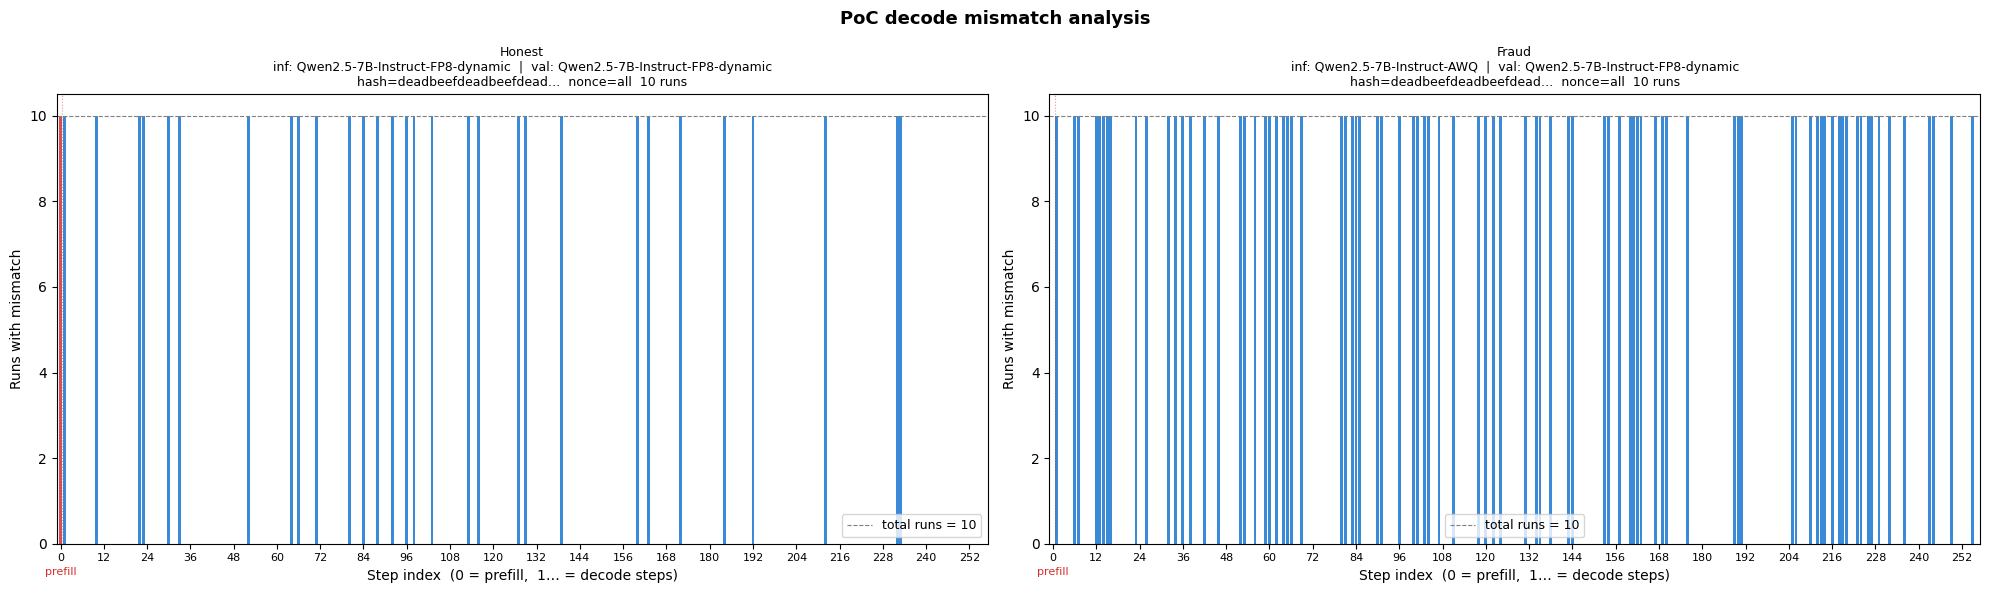

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path


def plot_mismatch_freq(ax, data_path, nonce=None, title_prefix=""):
    with open(data_path) as f:
        raw = json.load(f)

    meta = raw.get("meta", {})
    runs = raw["runs"]

    if nonce is not None:
        runs = [r for r in runs if r["nonce"] == nonce]

    if not runs:
        ax.set_title(f"{title_prefix}\nno runs for nonce={nonce}")
        return

    block_hash = runs[0]["block_hash"]
    n_steps = len(runs[0]["inference_sphere_k_steps"])
    n_total = len(runs)

    freq = np.zeros(n_steps, dtype=int)
    for r in runs:
        inf_k = r["inference_sphere_k_steps"]
        val_k = r["validation_sphere_k_steps"]
        for i, (a, b) in enumerate(zip(inf_k, val_k)):
            if a != b:
                freq[i] += 1

    positions = np.arange(n_steps)
    colors = ["#d32f2f" if pos == 0 else "#1976d2" for pos in positions]
    ax.bar(positions, freq, color=colors, width=0.8, alpha=0.85)

    inf_model  = meta.get("inference_model",  "?").split("/")[-1]
    val_model  = meta.get("validation_model", "?").split("/")[-1]
    shown_nonce = nonce if nonce is not None else "all"

    ax.set_xlabel("Step index  (0 = prefill,  1… = decode steps)", fontsize=10)
    ax.set_ylabel("Runs with mismatch", fontsize=10)
    ax.set_title(
        f"{title_prefix}\n"
        f"inf: {inf_model}  |  val: {val_model}\n"
        f"hash={block_hash[:20]}…  nonce={shown_nonce}  {n_total} runs",
        fontsize=9,
    )
    ax.set_xlim(-1, n_steps)
    ax.set_ylim(0, n_total + 0.5)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.axhline(n_total, color="gray", linewidth=0.8, linestyle="--",
               label=f"total runs = {n_total}")
    ax.axvline(0.5, color="#d32f2f", linewidth=0.8, linestyle=":", alpha=0.5)
    ax.text(0, -0.07, "prefill", ha="center", fontsize=8, color="#d32f2f",
            transform=ax.get_xaxis_transform())
    tick_every = max(1, n_steps // 20)
    ax.set_xticks(positions[::tick_every])
    ax.set_xticklabels(positions[::tick_every], fontsize=8)
    ax.legend(fontsize=9)


DATA_DIR = Path("../data/mismatch_per_step")

NONCE = None  # set to an int to filter by nonce, or None for all runs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("PoC decode mismatch analysis", fontsize=13, fontweight="bold")

plot_mismatch_freq(ax1, DATA_DIR / "20260429T083628Z/artifacts.json", nonce=NONCE, title_prefix="Honest")
plot_mismatch_freq(ax2, DATA_DIR / "20260429T083346Z/artifacts.json", nonce=NONCE, title_prefix="Fraud")

plt.tight_layout()
plt.show()

## Distribution

Hidden state distributions after prefill.

Samples: 1  |  hidden dim: 3584  |  sphere dim: 256


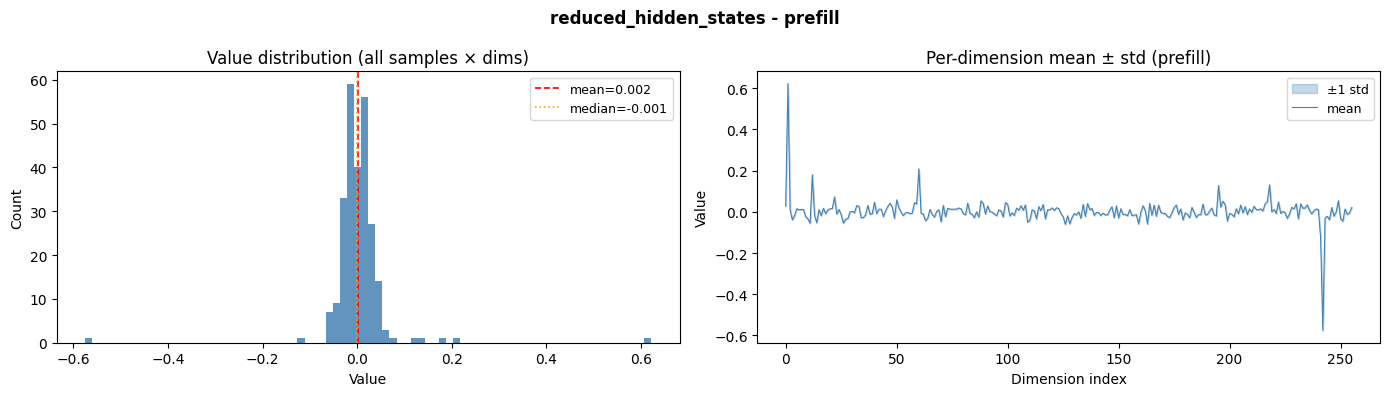

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

data = np.load("../data/dist_analysis/default.npz", allow_pickle=True)

block_hashes = data["block_hashes"]
nonces = data["nonces"]
hidden_states = data["hidden_states"]
reduced_hidden_states = data["reduced_hidden_states"]
sphere_k_steps = data["sphere_k_steps"]
reduced_hidden_states_decode = data["reduced_hidden_states_decode"]

N, D        = reduced_hidden_states.shape
_, n_steps  = sphere_k_steps.shape
n_decode    = reduced_hidden_states_decode.shape[1]

print(f"Samples: {N}  |  hidden dim: {hidden_states.shape[1]}  |  sphere dim: {D}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ---- left: histogram of all values across all samples & dimensions ----
flat = reduced_hidden_states.ravel()
axes[0].hist(flat, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].set_title("Value distribution (all samples × dims)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[0].axvline(flat.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={flat.mean():.3f}")
axes[0].axvline(np.median(flat), color="orange", linestyle=":", linewidth=1.2, label=f"median={np.median(flat):.3f}")
axes[0].legend(fontsize=9)

# ---- right: per-dimension mean ± std across samples ----
dim_mean = reduced_hidden_states.mean(axis=0)
dim_std  = reduced_hidden_states.std(axis=0)
x = np.arange(D)
axes[1].fill_between(x, dim_mean - dim_std, dim_mean + dim_std, alpha=0.3, color="steelblue", label="±1 std")
axes[1].plot(x, dim_mean, color="steelblue", linewidth=0.8, label="mean")
axes[1].set_title("Per-dimension mean ± std (prefill)")
axes[1].set_xlabel("Dimension index")
axes[1].set_ylabel("Value")
axes[1].legend(fontsize=9)

fig.suptitle("reduced_hidden_states - prefill", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

cmp = np.load("../data/dist_analysis/random_pick_based_prev.npz", allow_pickle=True)

cmp_block_hashes = cmp["block_hashes"]
cmp_nonces = cmp["nonces"]
cmp_rhs = cmp["reduced_hidden_states"]
cmp_rhs_dec = cmp["reduced_hidden_states_decode"]
cmp_k_steps = cmp["sphere_k_steps"]

M, D = cmp_rhs.shape
n_decode = cmp_rhs_dec.shape[1]

unique_hashes = list(dict.fromkeys(cmp_block_hashes))
unique_nonces = sorted(set(cmp_nonces.tolist()))

combos = [(h, n) for h in unique_hashes for n in unique_nonces]
combo_label = {(h, n): f"{h[:8]}… / n={n}" for h, n in combos}
hash_colors = {h: c for h, c in zip(unique_hashes, plt.rcParams["axes.prop_cycle"].by_key()["color"])}
nonce_styles = {n: s for n, s in zip(unique_nonces, ["-", "--", ":", "-."])}

def sample_mask(h, n):
    return (cmp_block_hashes == h) & (cmp_nonces == n)

print(f"Loaded {M} samples  |  hashes: {unique_hashes}  |  nonces: {unique_nonces}")

Loaded 4 samples  |  hashes: ['abc123', 'def456']  |  nonces: [42, 43]


### Reduced hidden-states decode — per step comparison

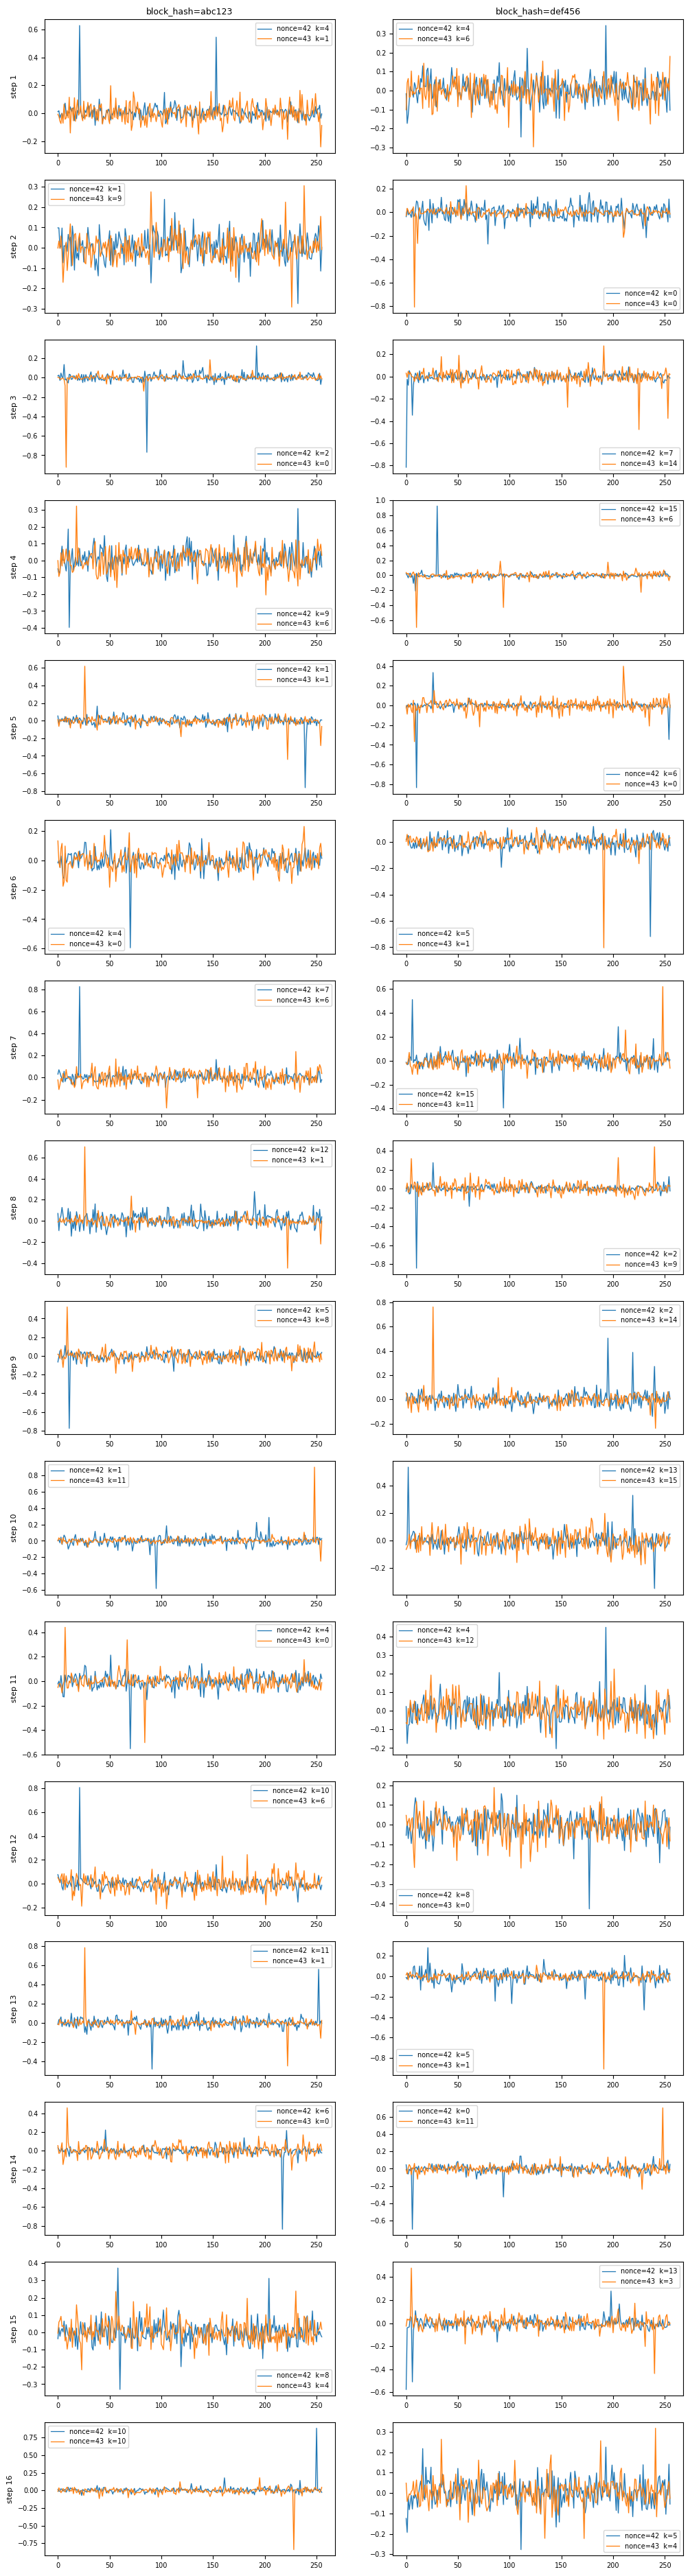

In [5]:
x = np.arange(D)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

n_cols = len(unique_hashes)

fig, axes = plt.subplots(n_decode, n_cols, figsize=(6 * n_cols, 3 * n_decode), squeeze=False)

for step in range(n_decode):
    for col, h in enumerate(unique_hashes):
        ax = axes[step][col]
        for ci, n in enumerate(unique_nonces):
            mask  = sample_mask(h, n)
            if not mask.any():
                continue
            vecs = cmp_rhs_dec[mask, step, :]
            mean_ = vecs.mean(axis=0)
            std_ = vecs.std(axis=0)
            col_ = colors[ci % len(colors)]

            k_vals_here = cmp_k_steps[mask, step + 1]
            k_str = ", ".join(str(k) for k in np.unique(k_vals_here))

            ax.fill_between(x, mean_ - std_, mean_ + std_, alpha=0.15, color=col_)
            ax.plot(x, mean_, color=col_, linewidth=0.9, label=f"nonce={n}  k={k_str}")

        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)
        if step == 0:
            ax.set_title(f"block_hash={h}", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"step {step + 1}", fontsize=8)

plt.show()

### Statistics across different hashes and nonces

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import mode as scipy_mode


def plot_mode_hist(ax, modes, title):
    k_vals = np.arange(modes.min(), modes.max() + 1)
    counts = np.array([(modes == k).sum() for k in k_vals])
    ax.bar(k_vals, counts, color="steelblue", edgecolor="white", linewidth=0.6)
    ax.set_xticks(k_vals)
    ax.set_title(title)
    ax.set_xlabel("Mode k")
    ax.set_ylabel("Number of samples")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))


def analyze_k_distribution(dh, dn, title="", seed=45):
    """Plot mode-k histograms and 4-random-sample distributions.

    dh: npz with sphere_k_steps shaped (n_hashes, n_steps)
    dn: npz with sphere_k_steps shaped (n_nonces, n_steps) and nonces array
    """
    dh_k_steps = dh["sphere_k_steps"]
    dn_k_steps = dn["sphere_k_steps"]

    n_hashes, n_steps = dh_k_steps.shape
    n_nonces = dn_k_steps.shape[0]

    mode_k_per_hash  = scipy_mode(dh_k_steps, axis=1).mode.ravel()
    mode_k_per_nonce = scipy_mode(dn_k_steps, axis=1).mode.ravel()

    print(f"{title}" if title else "", flush=True)
    print(f"diff hashes / one nonce : {n_hashes} hashes, {n_steps} steps each")
    print(f"  mode-k  min={mode_k_per_hash.min()}  max={mode_k_per_hash.max()}  "
          f"unique={np.unique(mode_k_per_hash)}")
    print(f"one hash / diff nonces  : {n_nonces} nonces, {n_steps} steps each")
    print(f"  mode-k  min={mode_k_per_nonce.min()}  max={mode_k_per_nonce.max()}  "
          f"unique={np.unique(mode_k_per_nonce)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_mode_hist(axes[0], mode_k_per_hash,  f"Mode k per hash  (n={n_hashes}, one nonce)")
    plot_mode_hist(axes[1], mode_k_per_nonce, f"Mode k per nonce  (n={n_nonces}, one hash)")
    fig.suptitle(
        f"{'[' + title + ']  ' if title else ''}Distribution of per-sample mode k  —  hashes vs nonces",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    rng    = np.random.default_rng(seed)
    k_vals = np.arange(
        min(dh_k_steps.min(), dn_k_steps.min()),
        max(dh_k_steps.max(), dn_k_steps.max()) + 1,
    )
    pick_hashes = rng.choice(n_hashes, size=min(4, n_hashes), replace=False)
    pick_nonces = rng.choice(n_nonces,  size=min(4, n_nonces),  replace=False)

    prefix = f"[{title}]  " if title else ""
    for plot_title, picks, k_data, modes, id_labels in [
        (f"{prefix}k distribution — 4 random hashes (one nonce each)",
         pick_hashes, dh_k_steps, mode_k_per_hash,
         [f"hash idx={i}" for i in pick_hashes]),
        (f"{prefix}k distribution — 4 random nonces (one hash each)",
         pick_nonces, dn_k_steps, mode_k_per_nonce,
         [f"nonce={dn['nonces'][i]}" for i in pick_nonces]),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(12, 6), squeeze=False)
        for ax, idx, lbl in zip(axes.ravel(), picks, id_labels):
            counts = np.array([(k_data[idx] == k).sum() for k in k_vals])
            ax.bar(k_vals, counts, color="steelblue", edgecolor="white", linewidth=0.4)
            ax.set_title(f"{lbl}  (mode k={modes[idx]})", fontsize=9)
            ax.set_xticks(k_vals)
            ax.set_xlabel("k", fontsize=8)
            ax.set_ylabel("Count", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        fig.suptitle(plot_title, fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

**Default setup:** we choose the same indexes for each hidden state after decoding when reducing. 

**Random setup:** we randomly choose the indexes for each hidden state after decoding.

default
diff hashes / one nonce : 100 hashes, 257 steps each
  mode-k  min=0  max=15  unique=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
one hash / diff nonces  : 100 nonces, 257 steps each
  mode-k  min=0  max=15  unique=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


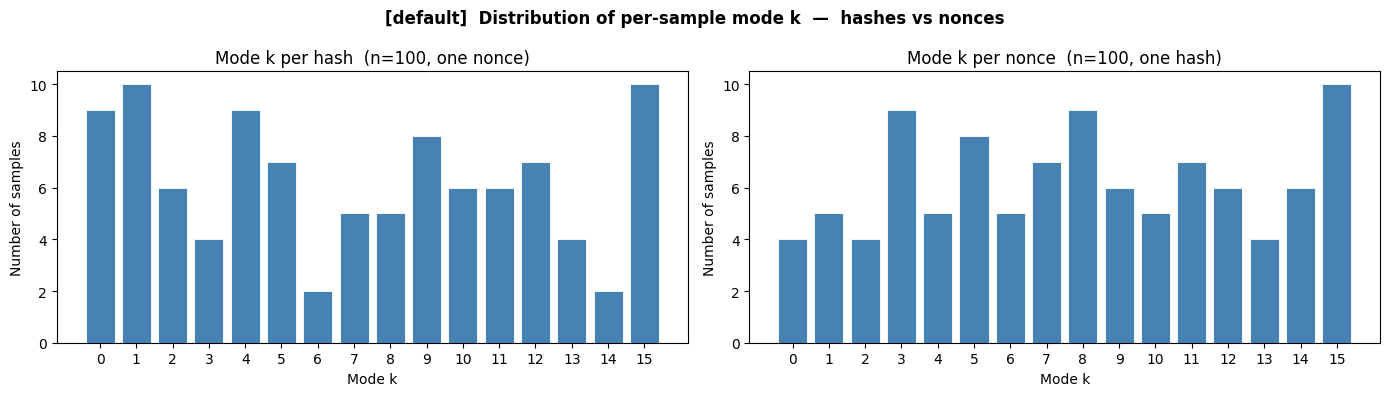

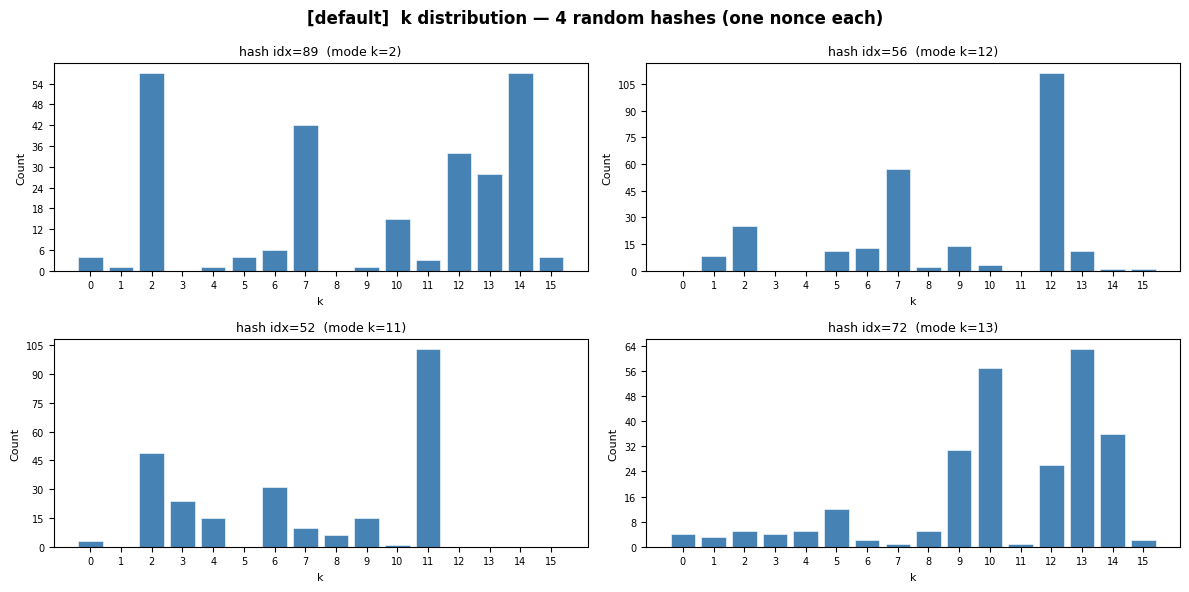

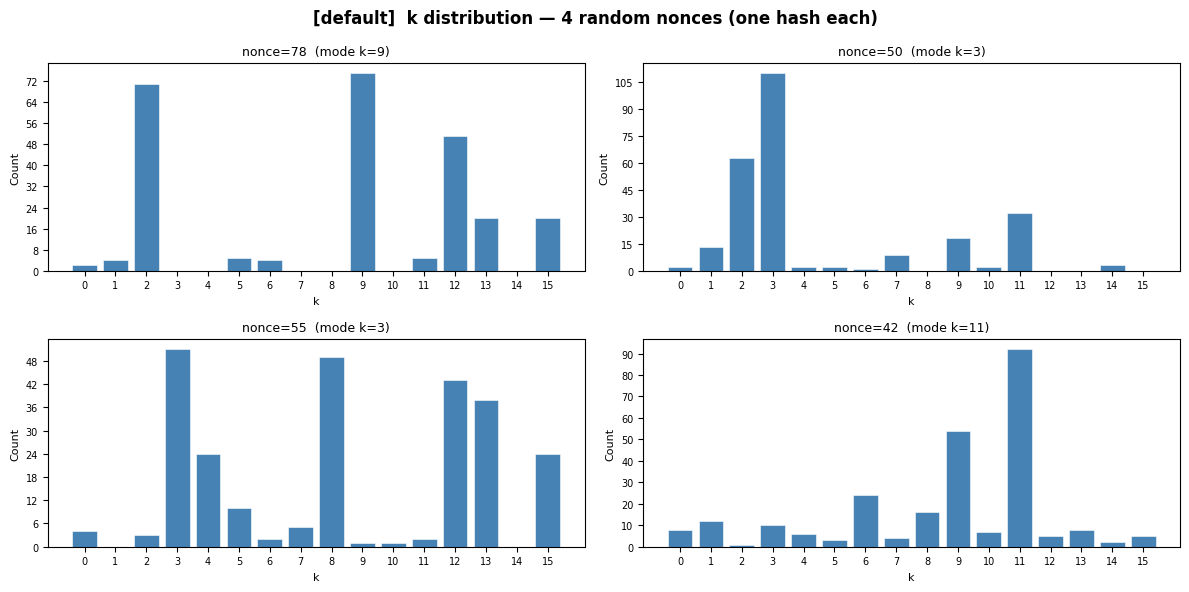

In [7]:
dh = np.load("../data/dist_analysis/default_diff_hashes_one_nonce.npz", allow_pickle=True)
dn = np.load("../data/dist_analysis/default_one_hashes_diff_nonce.npz", allow_pickle=True)
analyze_k_distribution(dh, dn, title="default")

random
diff hashes / one nonce : 100 hashes, 257 steps each
  mode-k  min=0  max=15  unique=[ 0  1  2  3  4  5  6  8  9 10 11 12 13 14 15]
one hash / diff nonces  : 100 nonces, 257 steps each
  mode-k  min=0  max=15  unique=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


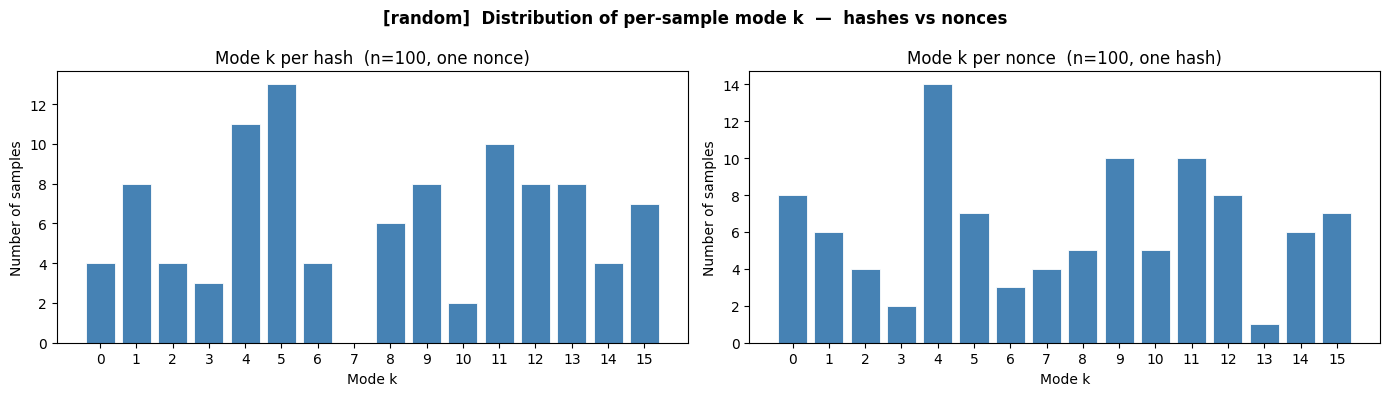

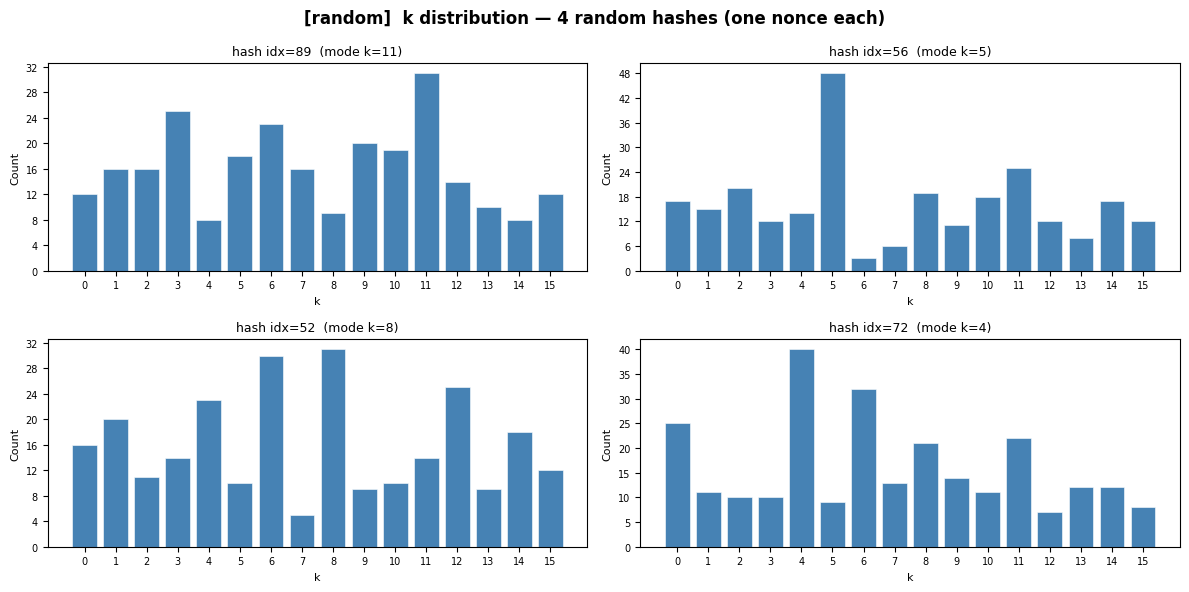

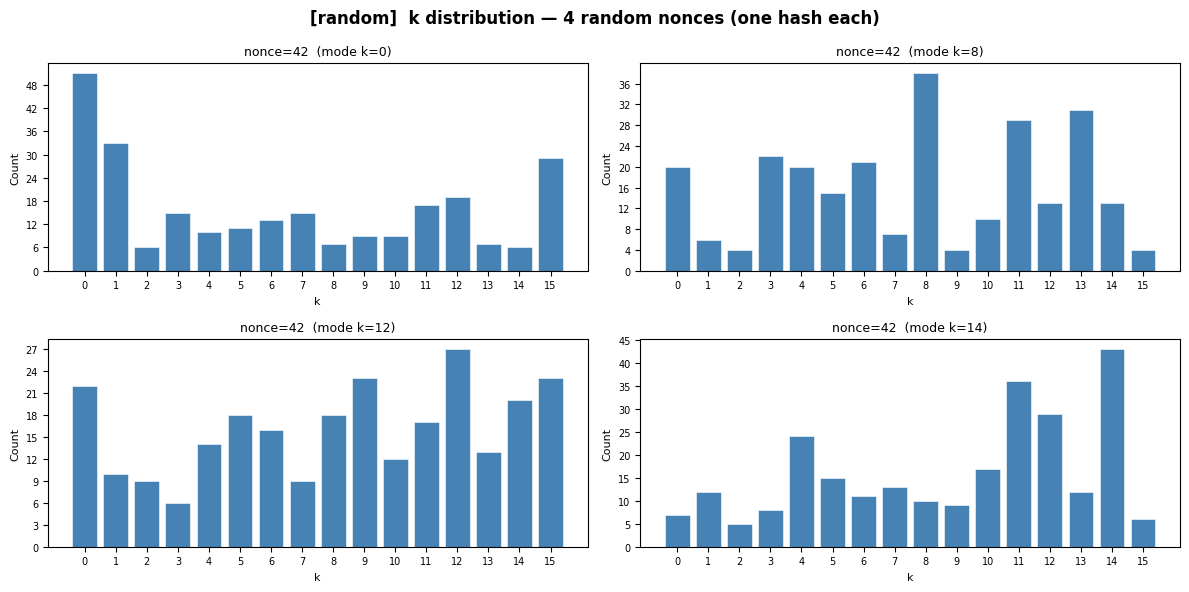

In [8]:
dh = np.load("../data/dist_analysis/random_diff_hashes_one_nonce.npz", allow_pickle=True)
dn = np.load("../data/dist_analysis/random_one_hash_diff_nonces.npz", allow_pickle=True)
analyze_k_distribution(dh, dn, title="random")